In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv


In [2]:
df= pd.read_csv(r'/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


# Data Cleaning

In [3]:
print(df.isnull().sum())
df=df.dropna(subset=['Customer ID'])
df.head()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
ref_date= df['InvoiceDate'].max()+ pd.Timedelta(days=1)


# RFM (Recency,Freq,Monentary)

In [5]:
df['TotalPrice']= df['Quantity']*df['Price']
rfm= df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x:(ref_date-x.max()).days,
'Invoice': 'nunique',
'TotalPrice': 'sum'})
rfm.columns=['Recency','Frequency','Monetary']
rfm.reset_index(inplace=True)
rfm

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,17,-64.68
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,5,4404.54
4,12350.0,310,1,334.40
...,...,...,...,...
5937,18283.0,4,22,2736.65
5938,18284.0,430,2,436.68
5939,18285.0,661,1,427.00
5940,18286.0,477,3,1188.43


In [6]:
Q1= rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)
IQR = Q3 - Q1

rfm = rfm[~((rfm < (Q1 - 1.5 * IQR)) | (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]
rfm

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,17,-64.68
2,12348.0,75,5,2019.40
3,12349.0,19,5,4404.54
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
...,...,...,...,...
5936,18282.0,8,3,176.60
5938,18284.0,430,2,436.68
5939,18285.0,661,1,427.00
5940,18286.0,477,3,1188.43


In [7]:
rfm['Average_order']= rfm['Monetary']/rfm['Frequency']
rfm

/tmp/ipykernel_16/1285635989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['Average_order']= rfm['Monetary']/rfm['Frequency']


,Customer ID,Recency,Frequency,Monetary,Average_order
0,12346.0,326,17,-64.68,-3.804706
2,12348.0,75,5,2019.40,403.880000
3,12349.0,19,5,4404.54,880.908000
4,12350.0,310,1,334.40,334.400000
5,12351.0,375,1,300.93,300.930000
...,...,...,...,...,...
5936,18282.0,8,3,176.60,58.866667
5938,18284.0,430,2,436.68,218.340000
5939,18285.0,661,1,427.00,427.000000
5940,18286.0,477,3,1188.43,396.143333


# KMeans Clustering

In [8]:
from sklearn.preprocessing import StandardScaler
features= ['Recency','Frequency','Monetary','Average_order']
scale=StandardScaler()
rfm_scaled=scale.fit_transform(rfm[features])

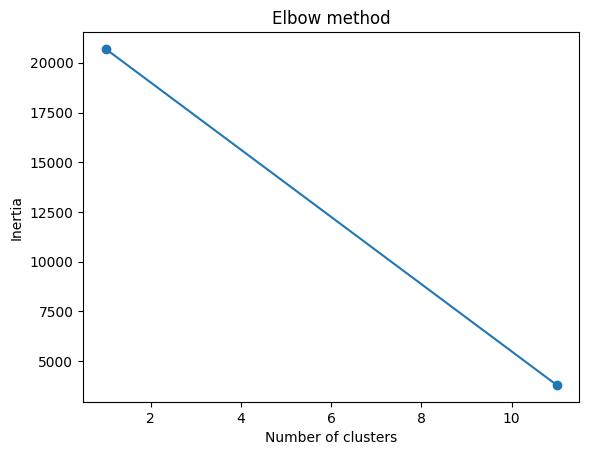

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia=[]
k_range=(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range,inertia,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()


In [10]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(rfm_scaled)
    score=silhouette_score(rfm_scaled,label)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.41256284697718604
k=3, Silhouette Score=0.4092991413966166
k=4, Silhouette Score=0.3821831983534172
k=5, Silhouette Score=0.3396959450215545
k=6, Silhouette Score=0.34886924407894754
k=7, Silhouette Score=0.33979681021499697
k=8, Silhouette Score=0.3041645141682678
k=9, Silhouette Score=0.30590538217902097
k=10, Silhouette Score=0.2927216513073308


In [11]:
kmeans=KMeans(n_clusters=4, random_state=42)
rfm['Clusters']=kmeans.fit_predict(rfm_scaled)
clust_Sum=rfm.groupby('Clusters')[features].mean()
print(clust_Sum)

             Recency  Frequency     Monetary  Average_order
Clusters                                                   
0         482.819558   2.051222   392.437562     197.302538
1          88.713450   3.340531   723.316735     233.602696
2         230.152941   2.415686  2056.145420     968.122279
3          81.551125  10.314928  2700.951028     281.939343


/tmp/ipykernel_16/1532762002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['Clusters']=kmeans.fit_predict(rfm_scaled)


# PCA Representation

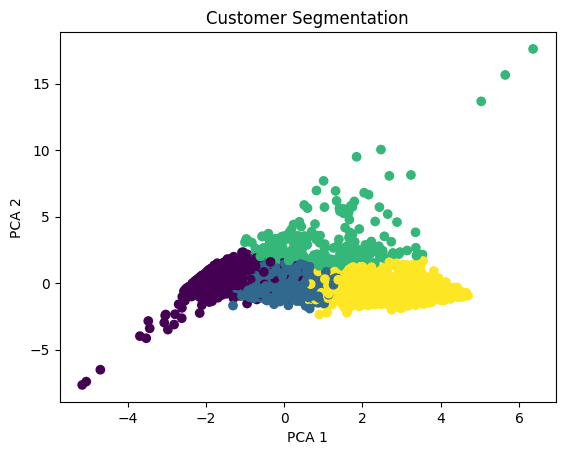

In [12]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
rfm_pca=pca.fit_transform(rfm_scaled)

plt.scatter(rfm_pca[:,0],rfm_pca[:,1],c=rfm['Clusters'])
plt.xlabel('PCA 1')
plt.ylabel("PCA 2")
plt.title("Customer Segmentation")
plt.show()

In [13]:

'''cluster_names = {
    0: "Churn Risk",
    1: "Regular Customers",
    2: "VIP",
    3: "Potential Loyalists"
}'''
summary=rfm.groupby('Clusters')[['Recency','Frequency','Monetary','Average_order']].mean().round(2)
summary

,Recency,Frequency,Monetary,Average_order
Clusters,,,,
0,482.82,2.05,392.44,197.30
1,88.71,3.34,723.32,233.60
2,230.15,2.42,2056.15,968.12
3,81.55,10.31,2700.95,281.94


# Strategy Creation


In [14]:
def recommend_strategy(row):
    c=row['Clusters']
    if c==1:
        return{
        "Segment": 'Potential Loyalist',
        "Action": "Nudge to repeat purchase",
        "Channel": 'Personalized Email',
        "Offer": 'Limited time coupon'
        }
    elif c==2:
        return{
        "Segment": 'Regular Customer',
        "Action": "Up sell and Cross sell",
        "Channel": 'Pop up recommendations',
        "Offer": 'Bundle Discounts'
        }
    elif c==3:
        return{
        "Segment": 'VIP customer',
        "Action": "Loyalty rewards, early access, premium support",
        "Channel": 'Email',
        "Offer": 'Exclusive discount, drop alerts'
        }
    else:
        return{
        "Segment": 'At risk',
        "Action": "Win back campaign",
        "Channel": 'Email and SMS',
        "Offer": 'Big discount, reminder'
        }
        
strat_df=rfm.apply(recommend_strategy,axis=1,result_type='expand')
rfm=pd.concat([rfm,strat_df],axis=1)
rfm
        


,Customer ID,Recency,Frequency,Monetary,Average_order,Clusters,Segment,Action,Channel,Offer
0,12346.0,326,17,-64.68,-3.804706,3,VIP customer,"Loyalty rewards, early access, premium support",Email,"Exclusive discount, drop alerts"
2,12348.0,75,5,2019.40,403.880000,1,Potential Loyalist,Nudge to repeat purchase,Personalized Email,Limited time coupon
3,12349.0,19,5,4404.54,880.908000,2,Regular Customer,Up sell and Cross sell,Pop up recommendations,Bundle Discounts
4,12350.0,310,1,334.40,334.400000,0,At risk,Win back campaign,Email and SMS,"Big discount, reminder"
5,12351.0,375,1,300.93,300.930000,0,At risk,Win back campaign,Email and SMS,"Big discount, reminder"
...,...,...,...,...,...,...,...,...,...,...
5936,18282.0,8,3,176.60,58.866667,1,Potential Loyalist,Nudge to repeat purchase,Personalized Email,Limited time coupon
5938,18284.0,430,2,436.68,218.340000,0,At risk,Win back campaign,Email and SMS,"Big discount, reminder"
5939,18285.0,661,1,427.00,427.000000,0,At risk,Win back campaign,Email and SMS,"Big discount, reminder"
5940,18286.0,477,3,1188.43,396.143333,0,At risk,Win back campaign,Email and SMS,"Big discount, reminder"


In [15]:
rfm.to_csv("customer_segmentation_final.csv", index=False)